In [15]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Plotting stuff
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay

# Confusion Matrices and ROC curves

In this notebook, we will ...

## Example - Kyphosis

Recall that in a previous lecture, we worked with the `kyphosis.csv`, which involved patients that may or may not have had conditions return after spinal surgery.

In [46]:
(kyphosis :=
 pl.read_csv('./sample_data/kyphosis.csv')
   .drop('rownames')
 )

Kyphosis,Age,Number,Start
str,i64,i64,i64
"""absent""",71,3,5
"""absent""",158,3,14
"""present""",128,4,5
"""absent""",2,5,1
"""absent""",1,4,15
…,…,…,…
"""present""",157,3,13
"""absent""",26,7,13
"""absent""",120,2,13


In [47]:
(X :=
 kyphosis
 .drop('Kyphosis')
 .to_pandas()
)

,Age,Number,Start
0,71,3,5
1,158,3,14
2,128,4,5
3,2,5,1
4,1,4,15
...,...,...,...
76,157,3,13
77,26,7,13
78,120,2,13
79,42,7,6


In [48]:
(y_raw :=
 kyphosis
 .select('Kyphosis')
)

Kyphosis
str
"""absent"""
"""absent"""
"""present"""
"""absent"""
"""absent"""
…
"""present"""
"""absent"""
"""absent"""


In [49]:
(uniq_labels :=
 y_raw
 .unique() # Make sure the positive case is first
 .get_column('Kyphosis')
 .to_numpy()
)

array(['present', 'absent'], dtype=object)

In [7]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_raw.get_column('Kyphosis'))
)

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

#### A train/test split

The most common application of these topics is when estimating the performance of a model using test data.  While we don't have a ton of data here, let's split the data for illustration sake.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y_ind, test_size=0.30,random_state=42, stratify=y_ind)

## Confusion Matrix

The [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) is a two-way table that compares the truth (true positive/negative) versus the prediction (predicted positive or negative.  The cells contain the number of occurances correspond
1. true positive,
2. true negative,
3. false positive, and
4. false negative.

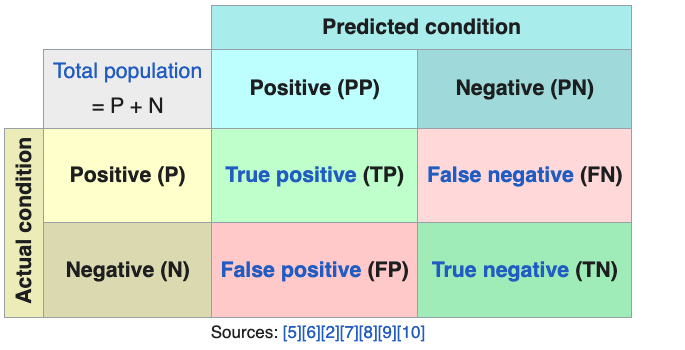
[screenshot source](https://en.wikipedia.org/wiki/Confusion_matrix)

### Example - Computing the confusion matrix for Logistic Regression.

In [9]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

(y_pred := log_reg.predict(X_test))

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0])

#### Test default `confusion_matrix` is BAD!

In [16]:
confusion_matrix(y_test, y_pred)

array([[19,  1],
       [ 2,  3]])

#### Better to display it with a plot from the estimated labels ...

This approach requires computing and saving the predicted classes.

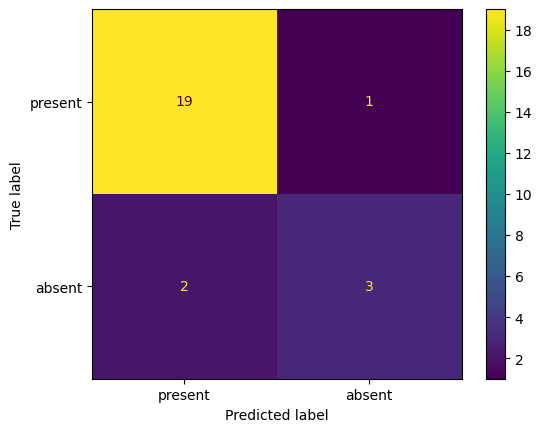

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred,
                                        display_labels=uniq_labels
                                       )

#### ... or using the fitted model and test data.

This approach avoids needing to compute the predicted classes, but **be sure to fit!**

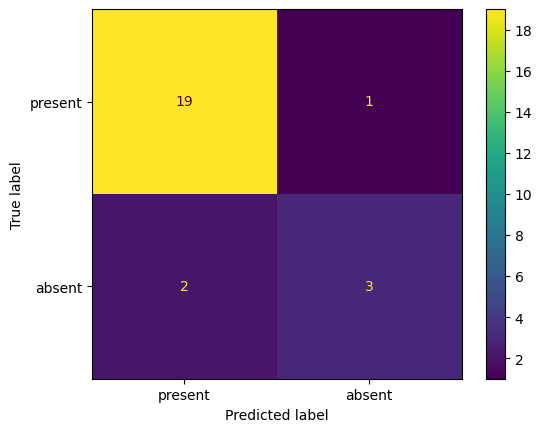

In [12]:
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, display_labels=uniq_labels)

### Using the confusion matrix entries to compute metrics.

We can use the entries as shown below.

In [17]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(19, 1, 2, 3)

#### Example - Computing the sensitivity

The [wikipedia page on sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) states that

1. $sensitivity = \frac{tp}{tp + fn}$
2. *Sensitivity refers to the test's ability to correctly detect ill patients out of those who do have the condition.*

In [18]:
(sensitivity := tp / (tp + fn))

0.6

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 60% of the subjects that truely have the condition.
</font>

## <font color="red"> Exercise 1 </font>

Compute the interpret the specificity when using Naive bayes as a classifier.

In [34]:
# Your code here (add cells as needed)
nb = GaussianNB()

In [35]:
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


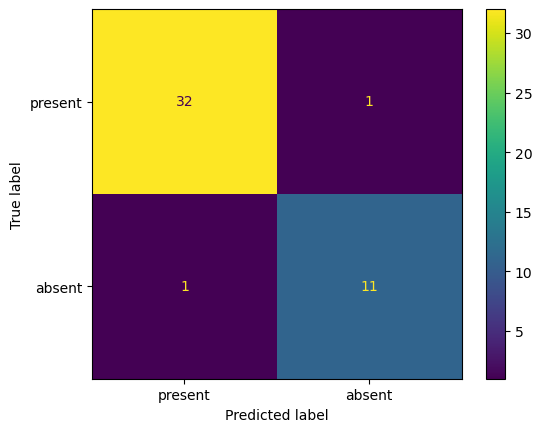

In [36]:
ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, display_labels=uniq_labels)

In [19]:
(spec := tn / (tn+fp))

0.95

<font color="orange">
Your interpretation here.
</font>

## Confusion matrics after a grid search

When our model has tuning parameters, we need

1. To perform a grid search first, then
2. Use the resulting gird search object as the "model".

In [23]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

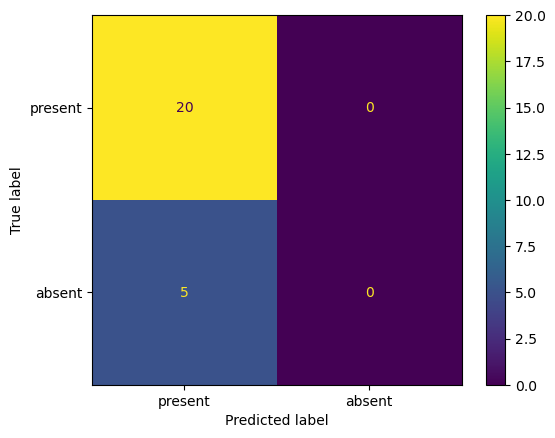

In [24]:
ConfusionMatrixDisplay.from_estimator(grid_search_knn,
                                      X_test,
                                      y_test,
                                      display_labels=uniq_labels)

In [25]:
y_pred_knn = grid_search_knn.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel().tolist()

In [26]:
(sensitivity := tp / (tp + fn))

0.0

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 0% of the subjects that truely have the condition.
</font>

In [27]:
(sensitivity := tp / (tp + fn))

0.0

<font color="orange">
When using logistic regression to estimate the presense of Kyphosis, the resulting model will correctly classify 60% of the subjects that truely have the condition.
</font>

## Topic 2 - ROC curves

The [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) is a way of

1. visualizing the performance of a classifier,
2. determining the best "cut-off" value when mistakes are penalized in different ways, and
3. Visually comparing the performance of a model.

Let's look at plotting ROC curves using `sklearn`

### Plotting a single ROC curve (no tuning parameters).

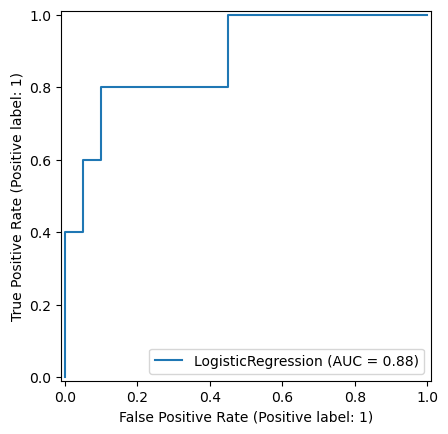

In [28]:
# Using the fitted model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

log_reg_disp = RocCurveDisplay.from_estimator(log_reg, X_test, y_test)

#### Plotting a single ROC curve (with tuning paramters).

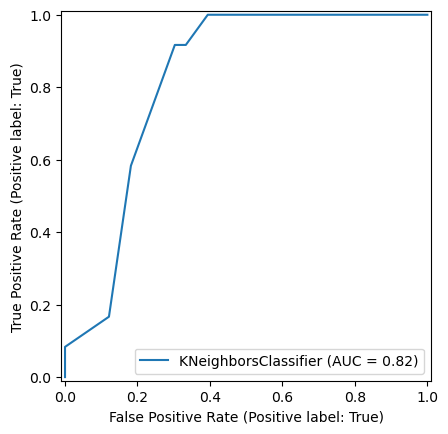

In [40]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn.fit(X_train, y_train)

knn_disp = RocCurveDisplay.from_estimator(grid_search_knn.best_estimator_, X_test, y_test)



#### Overlaying multiple ROC curves

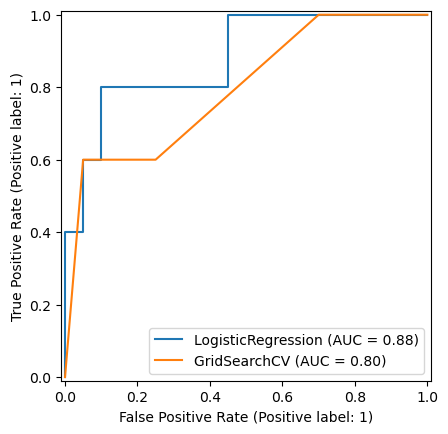

In [30]:
ax = plt.gca()
log_reg_disp.plot(ax=ax)
knn_disp.plot(ax=ax)

## ROC curves for cross validation

While it is possible to plot ROC curves for cross validation, `sklearn` lacks the tools to do this easily.  [This example](https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/auto_examples/plot_roc_crossval.html) illustrates how this might be accomplished with VERY UGLY CODE!

## <font color="red"> Exercise 2</font>

Make a plot of all five ROC curves, one for each of the classic classifiers and interpret the results.

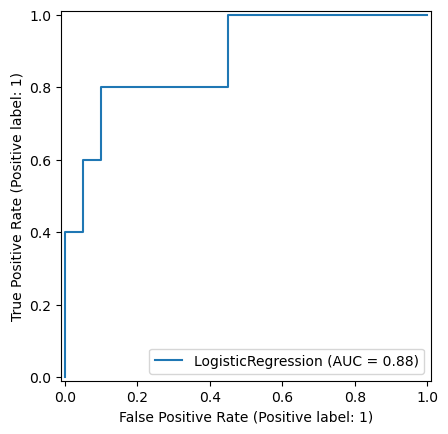

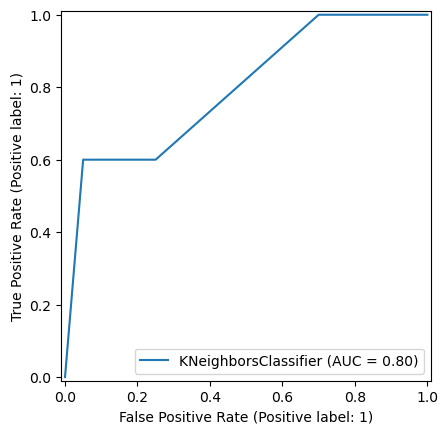

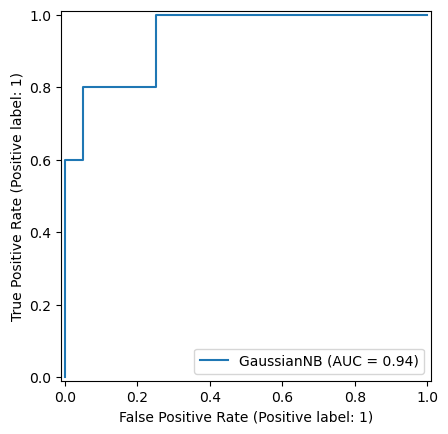

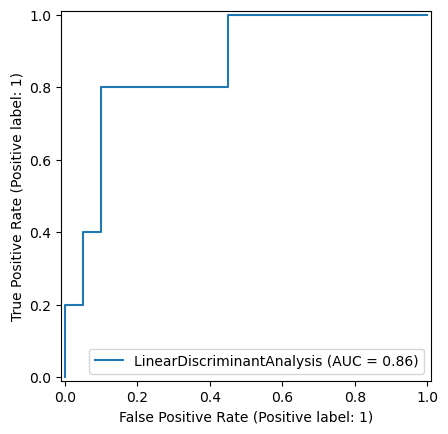

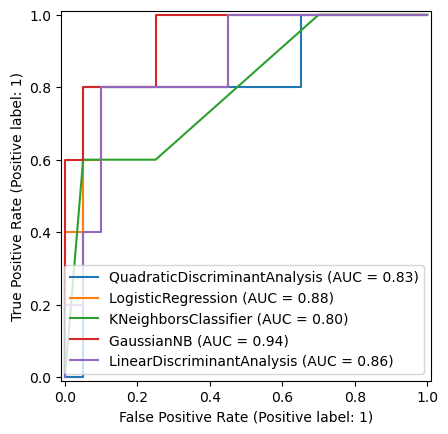

In [55]:
# Your code here (add cells as needed)
#log_reg, kNN, Naive Bayes, LDA,QDA
# We already did log_reg and kNN

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

log_reg_disp = RocCurveDisplay.from_estimator(log_reg, X_test, y_test)


kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring='roc_auc')
grid_search_knn.fit(X_train, y_train)

knn_disp = RocCurveDisplay.from_estimator(grid_search_knn.best_estimator_, X_test, y_test)


nb = GaussianNB()
nb.fit(X_train,y_train)

nb_disp = RocCurveDisplay.from_estimator(nb, X_test, y_test)



lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

lda_disp = RocCurveDisplay.from_estimator(lda,X_test, y_test)


qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

qda_disp = RocCurveDisplay.from_estimator(qda,X_test, y_test)


ax = plt.gca()
log_reg_disp.plot(ax=ax)
knn_disp.plot(ax=ax)
nb_disp.plot(ax= ax)
lda_disp.plot(ax= ax)





## <font color="red"> Exercise 3 - Add to Lab 3.1</font>

For the `diabetes_raw.csv` data, do each of the following.

1. Plot the confusion matrix for each of the classic classification methods, and
2. Compute the sensitivity and specificity of each.  
3. Identify the model with the best value of those metrics, and interpret these winning values in the context of the problem.
4. Make a visualization of the ROC curves overlaid on each plot.

In [56]:
(diabetes_raw :=

    pl.read_csv('./sample_data/diabetes_raw.csv')

)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
i64,i64,i64,i64,i64,f64,f64,i64,str
6,148,72,35,0,33.6,0.627,50,"""Yes"""
1,85,66,29,0,26.6,0.351,31,"""No"""
8,183,64,0,0,23.3,0.672,32,"""Yes"""
1,89,66,23,94,28.1,0.167,21,"""No"""
0,137,40,35,168,43.1,2.288,33,"""Yes"""
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,"""No"""
2,122,70,27,0,36.8,0.34,27,"""No"""
5,121,72,23,112,26.2,0.245,30,"""No"""


In [57]:
(X :=
 diabetes_raw
 .drop('Diabetes')
 .to_pandas()
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [59]:
(y_raw :=
 diabetes_raw
 .select('Diabetes')
)

Diabetes
str
"""Yes"""
"""No"""
"""Yes"""
"""No"""
"""Yes"""
…
"""No"""
"""No"""
"""No"""


In [66]:
(uniq_labels :=
 y_raw
 .unique() # Make sure the positive case is first
 .sort("Diabetes", descending=True)
 .get_column('Diabetes')
 .to_numpy()

)

array(['Yes', 'No'], dtype=object)

In [67]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_raw.get_column('Diabetes'))
)

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y_ind, test_size=0.30,random_state=42, stratify=y_ind)

c:\Users\lr7273ow\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


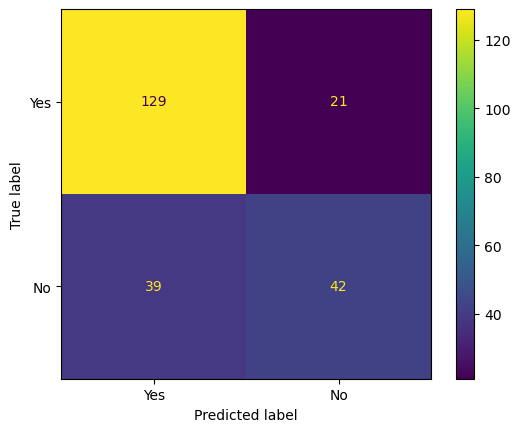

In [70]:
log_reg.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, display_labels=uniq_labels)


In [79]:
(y_pred := log_reg.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
(tn, fp, fn, tp)
#sensitvity log regression
(sensitivity := tp / (tp + fn))

#specificity log reg
(specificity := tn / (tn+fp))


print(sensitivity,specificity)


0.5185185185185185 0.86


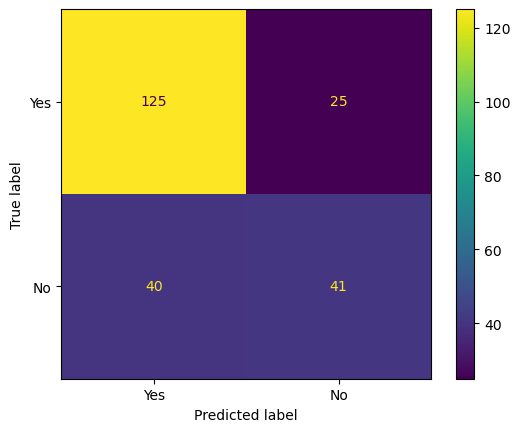

In [77]:
kNN.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(kNN, X_test, y_test, display_labels = uniq_labels)

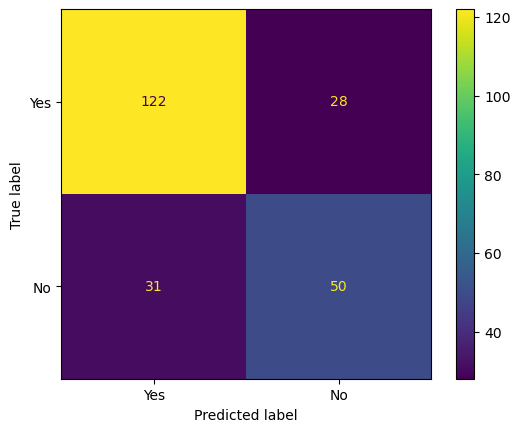

In [78]:
nb.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, display_labels = uniq_labels)

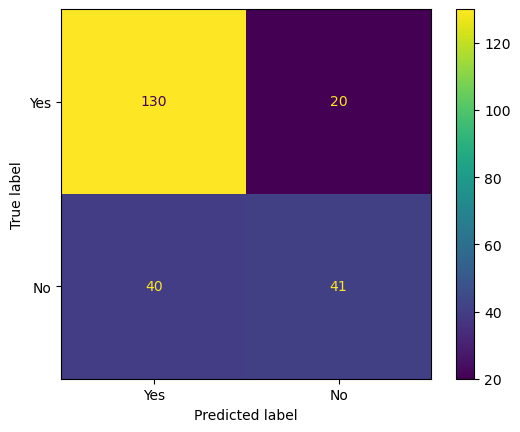

In [80]:
lda.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(lda, X_test, y_test, display_labels = uniq_labels)

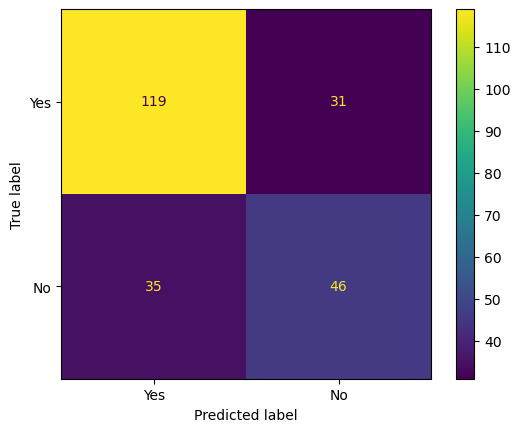

In [81]:
qda.fit(X_train, y_train)



ConfusionMatrixDisplay.from_estimator(qda, X_test, y_test, display_labels = uniq_labels)

### The ROC curves

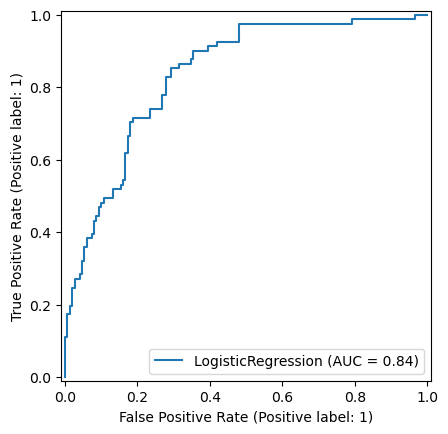

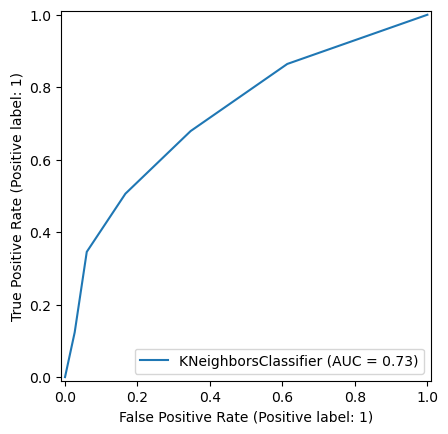

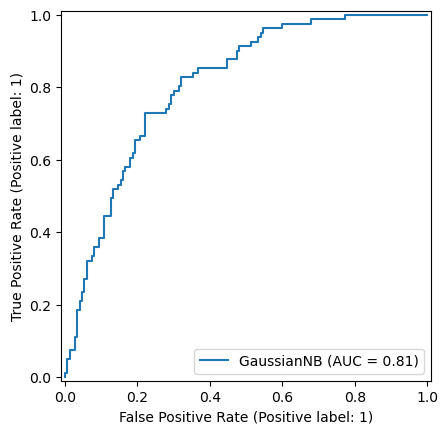

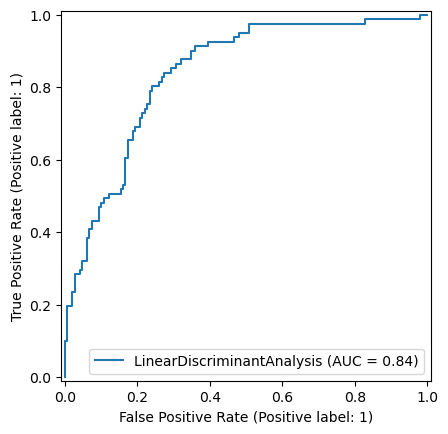

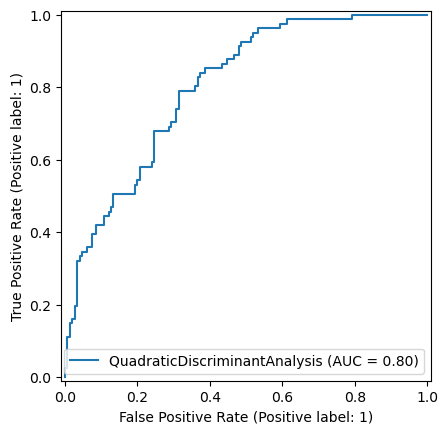

In [86]:
(log_reg_disp := RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
 )

(knn_disp := RocCurveDisplay.from_estimator(kNN, X_test, y_test))

(nb_disp := RocCurveDisplay.from_estimator(nb,X_test, y_test))

(lda_disp := RocCurveDisplay.from_estimator(lda,X_test, y_test))

(qda_disp := RocCurveDisplay.from_estimator(qda, X_test, y_test))

##### Overlaid

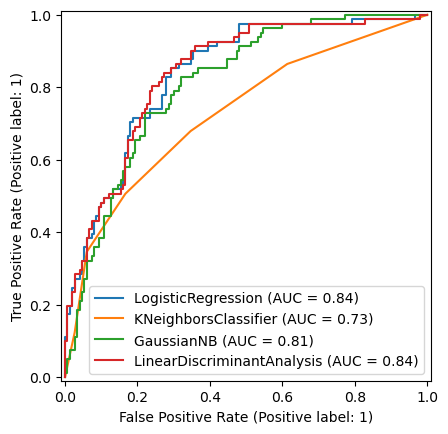

In [87]:
ax = plt.gca()
log_reg_disp.plot(ax=ax)
knn_disp.plot(ax=ax)
nb_disp.plot(ax= ax)
lda_disp.plot(ax= ax)

##### The model with the best AUC from the ROC curves would be Logistic Regression and Linear Discriminant Analysis

In [89]:
#Sensitivity for Logistic 
(y_pred_log := log_reg.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_log).ravel().tolist()
(tn, fp, fn, tp)
#sensitvity log regression
(sensitivity := tp / (tp + fn))

#specificity log reg
(specificity := tn / (tn+fp))


print(sensitivity,specificity)


0.5185185185185185 0.86


In [91]:
(y_pred_lda := lda.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lda).ravel().tolist()

#sensitivity lda 
(sensitivity := tp /(tp + fn))

#specificity
(specficity := tn / (tn +fp))


print(sensitivity,specificity)

0.5061728395061729 0.86
